# Exploration pyrekordbox

Ce notebook documente l'exploration de la base de données Rekordbox 6 via la librairie `pyrekordbox`.
L'objectif était de comprendre la structure des données pour construire le module `worker/rekordbox/extractor.py`
qui alimente l'API Diggy.

## Connexion à la base

`pyrekordbox` lit directement la base SQLite chiffrée de Rekordbox (`master.db`) depuis `AppData`. Rekordbox doit être installé sur la machine.

In [38]:
from pyrekordbox import Rekordbox6Database

db = Rekordbox6Database()

## Tracks — champs disponibles

Chaque track expose ses métadonnées via SQLAlchemy.
Les champs retenus pour l'import : `ID`, `Title`, `ArtistName`, `BPM` (÷100),
`Key.ScaleName`, `Length` (ms), `Rating`, `FolderPath`, `DateCreated`, `MyTagNames`.

In [39]:
tracks = list(db.get_content())
track = tracks[600]

{
    "id":           track.ID,
    "title":        track.Title,
    "artist":       track.Artist.Name if track.Artist else None,
    "album":        track.Album.Name if track.Album else None,
    "label":        track.Label.Name if track.Label else None,
    "bpm":          track.BPM / 100,
    "key":          track.Key.ScaleName if track.Key else None,
    "duration_ms":  track.Length,
    "rating":       track.Rating,
    "file_path":    track.FolderPath,
    "date_added":   track.DateCreated,
    "my_tags":      track.MyTagNames,
}

{}


{'id': '52608202',
 'title': 'Face to Face',
 'artist': 'Daft Punk',
 'album': 'Discovery',
 'label': None,
 'bpm': 117.88,
 'key': '1A',
 'duration_ms': 240,
 'rating': 3,
 'file_path': '/contents_2332759906/daft punk/discovery/face to face.mp3',
 'date_added': '2026-04-20',
 'my_tags': ['TO_ENERGY', 'TO_CUE', 'TO_LOOP', 'TO_COLOR', 'French Touch']}

## Cues — points de repère

Les cues sont les marqueurs posés dans Rekordbox (hot cues A–H, memory cues).
`Kind=0` → memory cue, `Kind=1..N` → hot cue A, B, C...
Triés par position en ms.

In [40]:
cues = list(db.get_cue())

by_track = {}
for c in cues:
    by_track.setdefault(c.ContentID, []).append(c)

sample_id = max(by_track, key=lambda k: len(by_track[k]))
track = next(t for t in tracks if str(t.ID) == str(sample_id))
print(f"{track.Title} — {track.Artist.Name} ({len(by_track[sample_id])} cues)\n")

def cue_label(kind):
    if kind == 0:
        return 'MEM'
    return chr(ord('A') + kind - 1)

for c in sorted(by_track[sample_id], key=lambda x: x.InMsec):
    print(f"  {cue_label(c.Kind)} | {c.InMsec}ms | Color={c.Color} | Loop={c.ActiveLoop}")

Wannabe — VOLAC (9 cues)

  A | 25ms | Color=-1 | Loop=None
  H | 15025ms | Color=255 | Loop=0
  B | 30025ms | Color=-1 | Loop=None
  C | 75025ms | Color=-1 | Loop=None
  E | 108775ms | Color=-1 | Loop=None
  F | 131275ms | Color=-1 | Loop=None
  G | 157525ms | Color=-1 | Loop=None
  I | 157525ms | Color=255 | Loop=0
  D | 157525ms | Color=255 | Loop=0


## MyTags — système de tags

Rekordbox permet de créer des tags personnalisés organisés en groupes.
Ici on extrait la structure complète et on filtre les tags réellement assignés à au moins un track.

In [41]:
tags = list(db.get_my_tag())
tag_songs = list(db.get_my_tag_songs())

used_tags = {s.MyTag.Name for s in tag_songs}
groups = {t.ID: t.Name for t in tags if t.Attribute == 1}

result = {name: [] for name in groups.values()}
for tag in tags:
    if tag.Attribute == 0 and tag.ParentID in groups and tag.Name in used_tags:
        result[groups[tag.ParentID]].append(tag.Name)

result = {k: v for k, v in result.items() if v}
result

{'ANALYSIS': ['IMPORTED', 'Deep House'],
 'PROCESS': ['TO_SORT',
  'TO_ENERGY',
  'TO_RATE',
  'TO_CUE',
  'TO_LOOP',
  'TO_COLOR'],
 'STYLE': ['Deep House',
  'Downtempo',
  'French Touch',
  'Electro Brut',
  'UK House',
  'Tech House',
  'Melodic Techno',
  'Classic/Min. Techno',
  'UK Garage',
  'Hard/Dark Techno',
  'Psytrance',
  'Trance Techno',
  'Nu-Disco',
  'Misc. Tracks'],
 'SOURCE': ['SoundCloud', 'Mix', 'Mix_001']}

### Tracks par tag

On peut aussi faire l'inverse : récupérer tous les tracks associés à un tag donné.

In [42]:
from collections import defaultdict

by_tag = defaultdict(list)
for s in tag_songs:
    by_tag[s.MyTag.Name].append(s.Content)

print(f"Total : {len(by_tag['Tech House'])} tracks\n")
for track in by_tag['Tech House']:
    print(f"{track.Title} — {track.Artist.Name} | {track.BPM / 100} BPM")

Total : 53 tracks

A Levels — GHSTGHSTGHST Sweet Pussy Pauline | 130.0 BPM
Actin' Tough — Dean Turnley | 140.0 BPM
Bad Man Sound — Mosimann Walshy Fire | 132.0 BPM
Bang (The Underground Doesn't Stop) (Original Version) — Laurent Garnier | 128.0 BPM
Bang't — Geeeman | 125.0 BPM
Banggg — O'Flynn | 130.0 BPM
Beat Boy — DJ Cream | 128.0 BPM
Besame — Manda Moor | 130.0 BPM
Beto’s Horns (fred remix) — Fred again.. CA7RIEL & Paco Amoroso | 127.66 BPM
Burnin' (Art Edit) — ANOTR Stef Davidse | 128.0 BPM
Cavaricci (The Carry Nation Remix) — Redance The Carry Nation | 127.0 BPM
Could Heaven Ever Be Like This (Walker & Royce and Chris Lorenzo Remix) — Idris Muhammad Walker & Royce Chris Lorenzo | 127.0 BPM
Dawn (Dub Edit) — z72.52 Justin Shawn Hobbs | 137.0 BPM
Direct Me (Joey Negro Mix) — The Reese Project Joey Negro | 121.82 BPM
Easy Rider — Royal Intention | 128.0 BPM
Es Vedra — Mosimann | 125.0 BPM
Fallin In Love (Butch Remix) — Duck Sauce A-Trak Armand Van Helden Butch | 127.0 BPM
Famosa — So

## Artworks

Rekordbox stocke les pochettes dans son dossier `share/PIONEER/Artwork/`.
Si le fichier n'existe pas encore (non généré par Rekordbox), on extrait l'image
directement depuis les tags ID3 du fichier audio via `mutagen`.

In [43]:
track = list(db.get_content())[0]
print(f"ImagePath (Rekordbox share) : {track.ImagePath}")
print(f"FolderPath (fichier audio)  : {track.FolderPath}")

ImagePath (Rekordbox share) : /PIONEER/Artwork/1af/08ede-c0c8-4e7d-a46e-a74d69b8f1f1/artwork.jpg
FolderPath (fichier audio)  : C:/Users/willi/Music/W_MIX/W - Misc. Tracks/Baxter - RAMBO.mp3


303 State (Original Mix) — Ramon Tapia & Kai Tracid


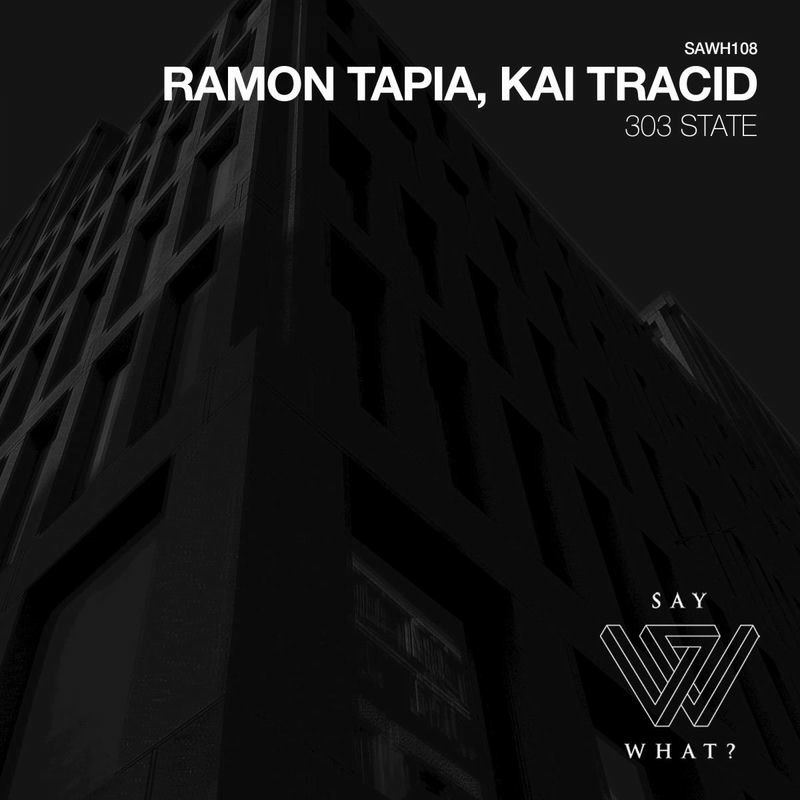

In [44]:
import os
from IPython.display import Image, display

RB_ARTWORK_ROOT = r"C:\Users\willi\AppData\Roaming\Pioneer\rekordbox\share"

# Cherche une track avec un artwork disponible
track_with_art = next(
    (t for t in tracks if t.ImagePath and os.path.exists(
        os.path.join(RB_ARTWORK_ROOT, t.ImagePath.lstrip("/").replace("/", os.sep))
    )),
    None
)

if track_with_art:
    artwork_path = os.path.join(RB_ARTWORK_ROOT, track_with_art.ImagePath.lstrip("/").replace("/", os.sep))
    print(f"{track_with_art.Title} — {track_with_art.Artist.Name if track_with_art.Artist else '?'}")
    display(Image(filename=artwork_path, width=200))
else:
    print("Aucun artwork trouvé")